# NB03 — SAE qwen25

In [1]:
import os, json, warnings, torch
import numpy as np
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

MODEL_TAG  = "qwen25"
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
SAE_EPOCHS    = 25
SAE_EXPANSION = 4
SAE_L1        = 1e-3
SAE_LR        = 1e-4
SAE_BATCH     = 64
ACT_SEQ_LEN   = 256

print(f"CUDA: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Model: {MODEL_NAME}")

CUDA: NVIDIA GeForce RTX 5080 Laptop GPU
VRAM: 17.1 GB
Model: Qwen/Qwen2.5-3B-Instruct


C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# SAE architecture
import torch.nn as nn

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, expansion_factor=4, l1_lambda=1e-3):
        super().__init__()
        hidden_dim = input_dim * expansion_factor
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.relu    = nn.ReLU()
        self.l1_lambda = l1_lambda
        nn.init.xavier_uniform_(self.encoder.weight)
        nn.init.xavier_uniform_(self.decoder.weight)

    def forward(self, x):
        x = x.float()
        h = self.relu(self.encoder(x))
        return self.decoder(h), h

    def get_loss(self, x):
        recon, h = self.forward(x)
        x = x.float()
        mse = nn.functional.mse_loss(recon, x)
        l1  = self.l1_lambda * h.abs().mean()
        l0  = (h > 0).float().mean()
        return mse + l1, {"mse": mse.item(), "l1": l1.item(), "l0": l0.item()}

In [3]:
# Load model + collect activations
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.bfloat16, device_map="auto")
model.eval()

num_layers = len(model.model.layers)
hidden_size = model.config.hidden_size
print(f"Loaded {MODEL_NAME}: {num_layers} layers, d={hidden_size}")

ACTIVATION_TEXTS = [
    "The mitochondria is the powerhouse of the cell.",
    "What are the main causes of inflation in developing economies?",
    "Write a Python function to implement binary search.",
    "The political implications of climate change are far-reaching.",
    "Explain quantum entanglement in simple terms.",
    "How do neural networks learn representations?",
    "The stock market crashed due to unexpected policy changes.",
    "Violence in media has been a subject of debate for decades.",
    "Medical diagnosis using AI has improved patient outcomes.",
    "The ethics of gene editing remain controversial.",
] * 100

activations = {i: [] for i in range(num_layers)}
hooks = []
def _make_hook(idx):
    def fn(mod, inp, out):
        h = out[0] if isinstance(out, tuple) else out
        activations[idx].append(h[:, -1, :].detach().cpu())
    return fn
for i in range(num_layers):
    hooks.append(model.model.layers[i].register_forward_hook(_make_hook(i)))

with torch.no_grad():
    for text in tqdm(ACTIVATION_TEXTS, desc="Collecting"):
        ids = tokenizer(text, return_tensors="pt", truncation=True,
                        max_length=ACT_SEQ_LEN).to(model.device)
        model(**ids)

for h in hooks: h.remove()
for i in activations: activations[i] = torch.cat(activations[i], dim=0)
print(f"Shape per layer: {activations[0].shape}")

Loading weights: 100%|██████████| 434/434 [00:02<00:00, 200.81it/s]


Loaded Qwen/Qwen2.5-3B-Instruct: 36 layers, d=2048


Collecting: 100%|██████████| 1000/1000 [00:44<00:00, 22.26it/s]


Shape per layer: torch.Size([1000, 2048])


In [4]:
# Train SAEs (25 epochs)
from torch.utils.data import DataLoader, TensorDataset

out_dir = f"sae_results/{MODEL_TAG}"
os.makedirs(out_dir, exist_ok=True)
layer_metrics = {}
device = "cuda" if torch.cuda.is_available() else "cpu"

for layer_idx in tqdm(range(num_layers), desc="Training SAEs"):
    acts = activations[layer_idx].to(device)
    sae = SparseAutoencoder(acts.shape[1], SAE_EXPANSION, SAE_L1).to(device)
    opt = torch.optim.Adam(sae.parameters(), lr=SAE_LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=SAE_EPOCHS)
    loader = DataLoader(TensorDataset(acts), batch_size=SAE_BATCH, shuffle=True)

    best_loss = float("inf")
    for epoch in range(SAE_EPOCHS):
        epoch_loss, epoch_m = 0.0, {"mse": 0, "l1": 0, "l0": 0}
        for (batch,) in loader:
            loss, m = sae.get_loss(batch)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item()
            for k in epoch_m: epoch_m[k] += m[k]
        n = len(loader)
        epoch_loss /= n
        for k in epoch_m: epoch_m[k] /= n
        best_loss = min(best_loss, epoch_loss)
        scheduler.step()

    layer_metrics[layer_idx] = {"final_loss": epoch_loss, "mse": epoch_m["mse"],
                                "l0_sparsity": epoch_m["l0"], "best_loss": best_loss}
    torch.save(sae.state_dict(), f"{out_dir}/sae_layer_{layer_idx}.pt")

print(f"Trained {num_layers} SAEs over {SAE_EPOCHS} epochs")

Training SAEs: 100%|██████████| 36/36 [01:25<00:00,  2.38s/it]

Trained 36 SAEs over 25 epochs


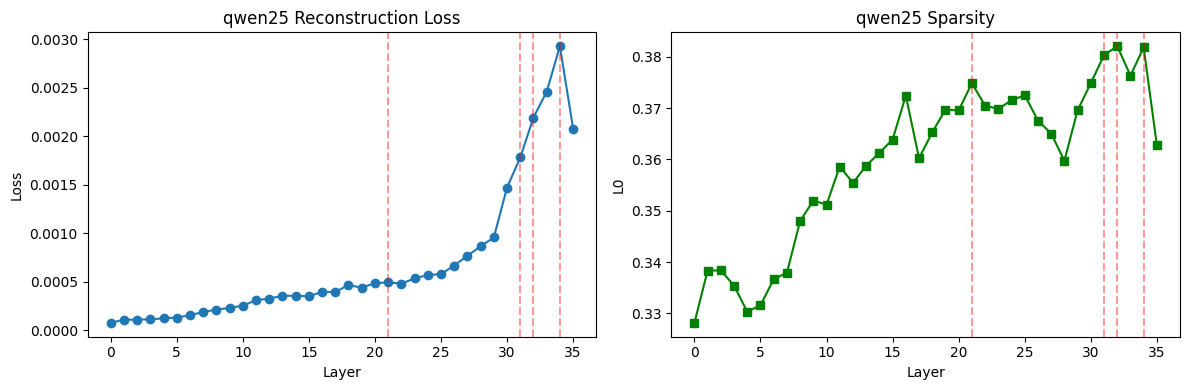

Probe layers for qwen25: [21, 31, 32, 34]


In [5]:
# Select probes
import matplotlib.pyplot as plt

mid_start = num_layers // 3
candidates = {k: v for k, v in layer_metrics.items() if k >= mid_start}
scores = {}
for k, v in candidates.items():
    scores[k] = -v["final_loss"] + 0.5 * (1.0 - abs(v["l0_sparsity"] - 0.4))

probe_layers = sorted(sorted(scores, key=scores.get, reverse=True)[:4])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
xs = sorted(layer_metrics.keys())
ax1.plot(xs, [layer_metrics[x]["final_loss"] for x in xs], "o-")
for p in probe_layers: ax1.axvline(p, color="red", alpha=0.4, ls="--")
ax1.set(xlabel="Layer", ylabel="Loss", title=f"{MODEL_TAG} Reconstruction Loss")
ax2.plot(xs, [layer_metrics[x]["l0_sparsity"] for x in xs], "s-", color="green")
for p in probe_layers: ax2.axvline(p, color="red", alpha=0.4, ls="--")
ax2.set(xlabel="Layer", ylabel="L0", title=f"{MODEL_TAG} Sparsity")
plt.tight_layout(); plt.show()

json.dump({"selected_probe_layers": probe_layers,
           "all_layer_metrics": {str(k): v for k, v in layer_metrics.items()},
           "model_tag": MODEL_TAG, "model_name": MODEL_NAME},
          open(f"{out_dir}/probe_layers.json", "w"), indent=2)
print(f"Probe layers for {MODEL_TAG}: {probe_layers}")

In [6]:
del model, activations
torch.cuda.empty_cache()
print("GPU freed.")

GPU freed.
